In [40]:
# Import the updated load_training_data function
from models.score_prediction import load_training_data

# Attempt to load the data from Supabase
try:
    df = load_training_data()
    print("Data loaded. Shape:", df.shape)
    df.head()  # Display the first few rows
except Exception as e:
    print("Error loading data:", e)


Data loaded. Shape: (1000, 38)


In [41]:
import os
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sqlalchemy import create_engine

from caching.supabase_client import supabase  # Import supabase client

# In a notebook, __file__ is not defined, so we use os.getcwd() instead
base_dir = os.getcwd()
MODEL_PATH = os.path.join(base_dir, 'score_prediction_model.pkl')

# Optional: Print the MODEL_PATH to verify it's correct
print("Model will be saved to:", MODEL_PATH)


Model will be saved to: /Users/mattb/Desktop/Projects/score-genius/notebooks/score_prediction_model.pkl


In [42]:
# Preprocess the data to create features (X) and target (y)
from models.score_prediction import preprocess_data

X, y = preprocess_data(df)
print("Features shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Features shape: (1000, 8)
Target shape: (1000,)


,home_q1,home_q2,home_q3,home_q4,score_ratio,rolling_home_score,rolling_away_score,prev_matchup_diff
8,23,29,21,23,0.457143,113.204,111.912000,0.0
71,28,31,28,26,0.518349,93.000,114.000000,0.0
111,33,28,26,29,0.557692,100.500,109.500000,0.0
119,34,25,27,26,0.513761,110.500,103.666667,0.0
151,19,24,24,31,0.457944,102.000,104.250000,0.0


In [43]:
from sklearn.model_selection import train_test_split

# Assuming you've already run the cell that defines X and y via preprocess_data(df)
X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Hold-out set shape:", X_holdout.shape)


Training set shape: (800, 8)
Hold-out set shape: (200, 8)


In [44]:
# Import the train_model and save_model functions from score_prediction.py
from models.score_prediction import train_model, save_model

# Train the model using our preprocessed data
model = train_model(X, y)

# Optionally, save the model to disk for later use
save_model(model)

Training MSE: 1.60
Test MSE: 7.07
Feature Importance:
               Feature  Importance
4         score_ratio    0.267469
0             home_q1    0.200311
1             home_q2    0.193742
2             home_q3    0.172774
3             home_q4    0.163601
6  rolling_away_score    0.001415
5  rolling_home_score    0.000687
7   prev_matchup_diff    0.000000
Model saved to /Users/mattb/Desktop/Projects/score-genius/backend/models/score_prediction_model.pkl


In [45]:
def compute_weighted_matchup_diff(row, df, weight_decay=0.9):
    """
    Computes a weighted average of (home_score - away_score) for past matchups
    between the same home and away teams, favoring more recent games.
    """
    home = row['home_team']
    away = row['away_team']
    current_date = row['game_date']

    # Filter for past games between the same teams
    past_games = df[
        (df['home_team'] == home) &
        (df['away_team'] == away) &
        (df['game_date'] < current_date)
    ].copy()

    if past_games.empty:
        return 0.0

    # Sort by date descending so the most recent game is first
    past_games.sort_values('game_date', ascending=False, inplace=True)

    # Calculate weights: [0.9^0, 0.9^1, 0.9^2, ...] for each prior game
    weights = [(weight_decay ** i) for i in range(len(past_games))]
    diff_series = past_games['home_score'] - past_games['away_score']

    weighted_sum = (diff_series * weights).sum()
    total_weights = sum(weights)

    return weighted_sum / total_weights

def preprocess_data(df):
    """
    Example of how to integrate the weighted matchup feature.
    """
    # Convert 'game_date' to datetime
    df.loc[:, 'game_date'] = pd.to_datetime(df['game_date'])

    # Sort and compute rolling averages (we’ll refine below)
    # ...
    
    # Weighted matchup difference
    df.loc[:, 'prev_matchup_diff'] = df.apply(
        lambda row: compute_weighted_matchup_diff(row, df, weight_decay=0.9),
        axis=1
    )

    # Define feature columns (include 'prev_matchup_diff')
    # ...


In [46]:
# For the home team rolling score:
df.loc[:, 'rolling_home_score'] = df.groupby('home_team')['home_score'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).median()
)

# For the away team rolling score:
df.loc[:, 'rolling_away_score'] = df.groupby('away_team')['away_score'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).median()
)

# Fill missing values if needed
df.loc[:, 'rolling_home_score'] = df['rolling_home_score'].fillna(df['home_score'].median())
df.loc[:, 'rolling_away_score'] = df['rolling_away_score'].fillna(df['away_score'].median())


In [47]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05],
    'max_depth': [2, 3]
}

gb_regressor = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(
    gb_regressor,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)
print("Best Parameters:", grid_search.best_params_)
print("Best Score (MSE):", -grid_search.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best Score (MSE): 6.689202658674231


In [48]:
%pip install xgboost  # If not installed

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05],
    'max_depth': [2, 3],
    'subsample': [0.8, 1.0],         # Randomly sample rows
    'colsample_bytree': [0.8, 1.0]   # Randomly sample features
}

xgb_regressor = XGBRegressor(random_state=42)
xgb_grid_search = GridSearchCV(
    xgb_regressor,
    xgb_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X, y)
print("Best XGB Parameters:", xgb_grid_search.best_params_)
print("Best XGB Score (MSE):", -xgb_grid_search.best_score_)


Note: you may need to restart the kernel to use updated packages.
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best XGB Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best XGB Score (MSE): 5.710376358032226


In [49]:
from xgboost import XGBRegressor

# Use the best parameters from GridSearchCV
final_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
final_xgb.fit(X, y)  # You can use your full training data here

# Save the final model if needed
import joblib
joblib.dump(final_xgb, 'final_xgb_model.pkl')


['final_xgb_model.pkl']

In [50]:
# Assuming X_holdout and y_holdout are defined from your train_test_split
holdout_preds = final_xgb.predict(X_holdout)
holdout_mse = ((y_holdout - holdout_preds) ** 2).mean()
print("Final XGBoost Hold-Out MSE:", holdout_mse)


Final XGBoost Hold-Out MSE: 1.83210495354695


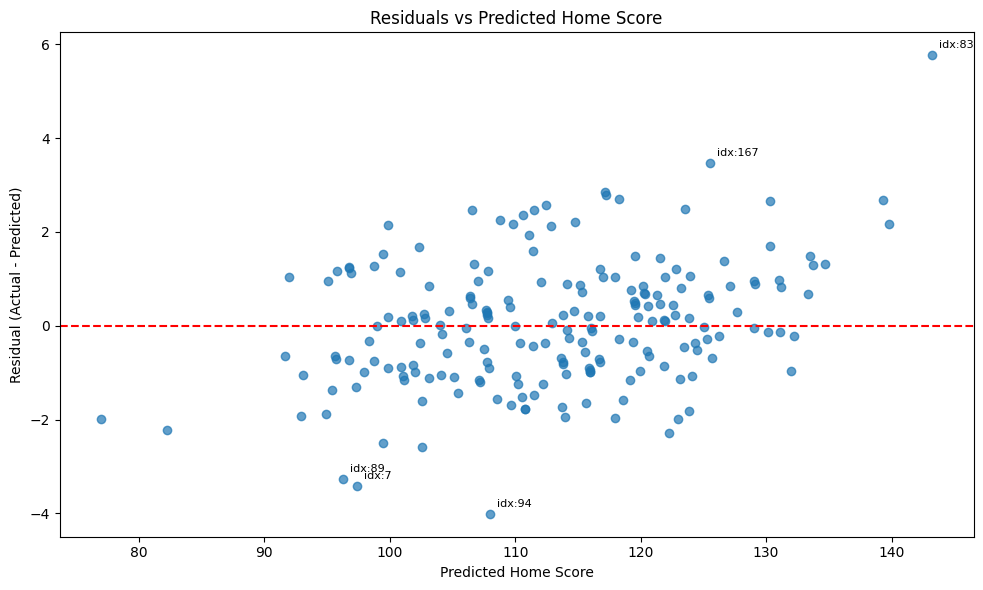

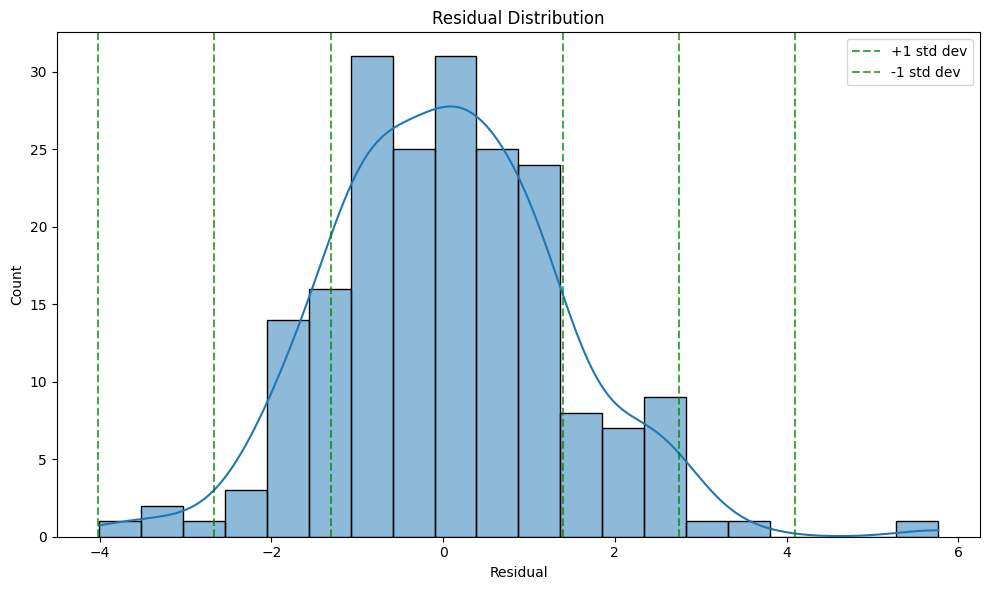


Top outliers:
   Index  Actual   Predicted  Residual  Abs_Residual
1     83     149  143.236679  5.763321      5.763321
3     94     104  108.008499 -4.008499      4.008499
4    167     129  125.541229  3.458771      3.458771
0      7      94   97.409500 -3.409500      3.409500
2     89      93   96.271820 -3.271820      3.271820


"\n# To save the outlier information for later analysis:\noutlier_df.to_csv('nba_prediction_outliers.csv', index=False)\n"

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# First, make sure to calculate residuals
# If you're getting errors about residuals not being defined, run this first:
residuals = y_holdout - holdout_preds

# 1. SCATTER PLOT WITH OUTLIER ANNOTATIONS
plt.figure(figsize=(10, 6))

# Convert to numpy arrays to avoid any indexing issues
residuals_np = np.array(residuals)
holdout_preds_np = np.array(holdout_preds)
y_holdout_np = np.array(y_holdout)

# Create the scatter plot
plt.scatter(holdout_preds_np, residuals_np, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')

# Define outlier threshold (adjust as needed)
outlier_threshold = 3  # Points with residuals beyond 3 points

# Annotate outliers
for i in range(len(residuals_np)):
    if abs(residuals_np[i]) > outlier_threshold:
        plt.annotate(f"idx:{i}", 
                    (holdout_preds_np[i], residuals_np[i]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8)

plt.xlabel('Predicted Home Score')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs Predicted Home Score')
plt.tight_layout()
plt.show()

# 2. HISTOGRAM WITH STANDARD DEVIATION MARKERS
plt.figure(figsize=(10, 6))
sns.histplot(residuals_np, kde=True, bins=20)
plt.xlabel('Residual')
plt.title('Residual Distribution')

# Add vertical lines for standard deviations
std_dev = np.std(residuals_np)
mean = np.mean(residuals_np)
for i in range(1, 4):
    plt.axvline(mean + i*std_dev, color='green', linestyle='--', alpha=0.7, 
               label=f"+{i} std dev" if i==1 else None)
    plt.axvline(mean - i*std_dev, color='green', linestyle='--', alpha=0.7,
               label=f"-{i} std dev" if i==1 else None)

plt.legend()
plt.tight_layout()
plt.show()

# 3. OUTLIER TABLE CREATION
# Find outliers beyond threshold
outliers = []
for i in range(len(residuals_np)):
    if abs(residuals_np[i]) > outlier_threshold:
        outliers.append({
            'Index': i,
            'Actual': y_holdout_np[i],
            'Predicted': holdout_preds_np[i],
            'Residual': residuals_np[i],
            'Abs_Residual': abs(residuals_np[i])
        })

# Create and display outlier DataFrame
if outliers:
    outlier_df = pd.DataFrame(outliers)
    outlier_df = outlier_df.sort_values('Abs_Residual', ascending=False)
    print("\nTop outliers:")
    print(outlier_df)
else:
    print("No outliers found beyond threshold:", outlier_threshold)

# 4. CODE TO CONNECT OUTLIERS TO YOUR GAME DATA
"""
# Assuming you have a dataframe called 'games_df' with game information:
# Replace 'games_df' with the actual name of your dataframe containing game details

if 'games_df' in globals():
    # Get the indices of your outliers
    outlier_indices = outlier_df['Index'].tolist()
    
    # Extract the corresponding game information
    # This assumes your games_df has the same indices or a way to map back
    game_data = games_df.iloc[outlier_indices]
    
    # Combine with outlier information
    game_outliers = pd.concat([outlier_df.set_index('Index'), 
                              game_data[['home_team', 'away_team', 'game_date']]], 
                              axis=1, join='inner')
    
    print("\nGame details for outliers:")
    print(game_outliers)
"""

# 5. SAVING FOR FUTURE REFERENCE
"""
# To save the outlier information for later analysis:
outlier_df.to_csv('nba_prediction_outliers.csv', index=False)
"""

In [52]:
# For example, using your final tuned XGBoost model (final_xgb)
train_preds = final_xgb.predict(X_train)
training_mse = ((y_train - train_preds) ** 2).mean()
print("Training MSE:", training_mse)


Training MSE: 1.609089090325142


In [53]:
holdout_preds = final_xgb.predict(X_holdout)
holdout_mse = ((y_holdout - holdout_preds) ** 2).mean()
print("Hold-out MSE:", holdout_mse)


Hold-out MSE: 1.83210495354695


In [54]:
# Assuming final_xgb is your final XGBoost model trained with tuned parameters
# and X_train, X_holdout, y_train, y_holdout have been defined

# Evaluate on training set
train_preds = final_xgb.predict(X_train)
training_mse = ((y_train - train_preds) ** 2).mean()
print("Training MSE:", training_mse)

# Evaluate on hold-out set
holdout_preds = final_xgb.predict(X_holdout)
holdout_mse = ((y_holdout - holdout_preds) ** 2).mean()
print("Hold-out MSE:", holdout_mse)


Training MSE: 1.609089090325142
Hold-out MSE: 1.83210495354695
